In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE          # replaced RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
print("Libraries loaded. SMOTE active for imbalance handling.")


Libraries loaded. SMOTE active for imbalance handling.


In [ ]:
!pip install catboost -q

## A. Load the Train / Test Datasets

The college provided two separate CSV files. Column names differ slightly between them,
so we apply a rename map to ensure both share the exact same schema before any processing.


In [ ]:
train_path = 'Train.csv'
test_path  = 'Test.csv'

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

rename_map = {
    'work-class': 'workclass',
    'work-fnl':   'fnlwgt',
    'position':   'occupation'
}
train_df = train_df.rename(columns=rename_map)
test_df  = test_df.rename(columns=rename_map)

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
print('Columns match:', list(train_df.columns) == list(test_df.columns))
display(train_df.head())

Train shape: (22792, 15)
Test shape:  (9769, 15)
Columns match: True


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# **B. Data Overview**




**1-train data**

In [ ]:
def data_info(data):

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

In [ ]:
data_info(train_df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[23, 33, 37, 31, 36, 34, 35, 30, 25, 28]",71,0,0.0,15
1,workclass,object,"[ Private, Self-emp-not-inc, Local-gov, ?, ...",9,0,0.0,15
2,fnlwgt,int64,"[164190, 203488, 190290, 155659, 126675, 12301...",16594,0,0.0,15
3,education,object,"[ HS-grad, Some-college, Bachelors, Masters...",16,0,0.0,15
4,education-num,int64,"[9, 10, 13, 14, 11, 7, 12, 6, 4, 15]",16,0,0.0,15
5,marital-status,object,"[ Married-civ-spouse, Never-married, Divorce...",7,0,0.0,15
6,occupation,object,"[ Prof-specialty, Craft-repair, Exec-manager...",15,0,0.0,15
7,relationship,object,"[ Husband, Not-in-family, Own-child, Unmarr...",6,0,0.0,15
8,race,object,"[ White, Black, Asian-Pac-Islander, Amer-In...",5,0,0.0,15
9,sex,object,"[ Male, Female]",2,0,0.0,15


In [ ]:
train_df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
age,22792.000000,38.593542,13.657228,17.000000,28.000000,37.000000,48.000000,90.000000
fnlwgt,22792.000000,189633.717138,104966.047094,12285.000000,118376.000000,178384.000000,236789.000000,1484705.000000
education-num,22792.000000,10.084065,2.556860,1.000000,9.000000,10.000000,12.000000,16.000000
capital-gain,22792.000000,1061.232757,7342.691929,0.000000,0.000000,0.000000,0.000000,99999.000000
capital-loss,22792.000000,86.730037,400.970842,0.000000,0.000000,0.000000,0.000000,4356.000000
hours-per-week,22792.000000,40.409705,12.283072,1.000000,40.000000,40.000000,45.000000,99.000000


<ul>
<li>No null values were detected in the dataset.</li>
<li>education and education-num contain almost the same information, which may lead to multicollinearity.</li>
<li>work-fnl has very high variance and may behave as a noisy feature.</li>
<li>hours-per-week contains outliers since most values are around 40–45 hours while the maximum reaches 99.</li>
<li>"capital-gain" all values till 75% is zero and the maximum is 99999.000000 [the is outliers + very skewed] ++ the same as "capital-loss".</li>
<li>IQR was more suitable than Z-score for outlier handling due to the skewed numerical distributions.</li>
</ul>

2-test data

In [ ]:
data_info(test_df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[36, 34, 28, 31, 35, 38, 29, 32, 41, 27]",73,0,0.0,1
1,workclass,object,"[ Private, Self-emp-not-inc, Local-gov, ?, ...",9,0,0.0,1
2,fnlwgt,int64,"[188246, 148995, 126569, 125000, 82393, 119793...",8400,0,0.0,1
3,education,object,"[ HS-grad, Some-college, Bachelors, Masters...",16,0,0.0,1
4,education-num,int64,"[9, 10, 13, 14, 11, 7, 12, 6, 4, 15]",16,0,0.0,1
5,marital-status,object,"[ Married-civ-spouse, Never-married, Divorce...",7,0,0.0,1
6,occupation,object,"[ Exec-managerial, Craft-repair, Prof-specia...",15,0,0.0,1
7,relationship,object,"[ Husband, Not-in-family, Own-child, Unmarr...",6,0,0.0,1
8,race,object,"[ White, Black, Asian-Pac-Islander, Amer-In...",5,0,0.0,1
9,sex,object,"[ Male, Female]",2,0,0.0,1


In [ ]:
test_df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
age,9769.000000,38.553895,13.601824,17.000000,28.000000,37.000000,48.000000,90.000000
fnlwgt,9769.000000,190115.847170,106904.593461,13769.000000,116934.000000,178344.000000,237920.000000,1161363.000000
education-num,9769.000000,10.072781,2.609464,1.000000,9.000000,10.000000,12.000000,16.000000
capital-gain,9769.000000,1115.949125,7483.978211,0.000000,0.000000,0.000000,0.000000,99999.000000
capital-loss,9769.000000,88.642543,407.581386,0.000000,0.000000,0.000000,0.000000,4356.000000
hours-per-week,9769.000000,40.502201,12.496683,1.000000,40.000000,40.000000,45.000000,99.000000


<ul>
<li>Some categorical columns contain "?", which should be treated as hidden missing values during preprocessing.</li>
<li>native-country has high cardinality with many unique categories, but most records belong to United-States.</li>
<li>sex and salary are binary categorical features, making them easy to encode and suitable for classification tasks.</li>
<li>occupation and workclass contain multiple categories that may strongly influence salary prediction.</li>
<li>age values are mainly concentrated in adulthood and middle age ranges, indicating fewer extreme young or old cases.</li>
<li>data almost the same as train, there is no shift .</li>
</ul>


# **C. EDA (Exploratory Data Analysis)**




#### **1.ckeck nulls**

In [ ]:
display(train_df.isna().sum())

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


#### **2.visualisations**

**i-target_column**

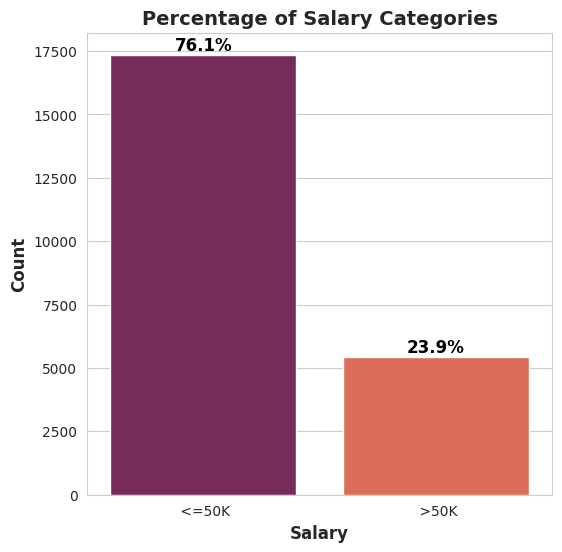

In [ ]:
sns.set_style("whitegrid")

salary_counts = train_df["salary"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
ax = sns.barplot(x=salary_counts.index, y=train_df["salary"].value_counts(), palette="rocket")

plt.title("Percentage of Salary Categories", fontsize=14, fontweight='bold')
plt.xlabel("Salary", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

for p, percentage in zip(ax.patches, salary_counts.values):
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')

plt.show()

In [ ]:
cat_cols = []
for col in train_df.columns:
    if train_df[col].dtypes == "object" or train_df[col].dtypes =="category" :
        cat_cols.append(col)

num_cols = []
for col in train_df.columns:
    if train_df[col].dtypes == "float64" or train_df[col].dtypes =="int64" :
        num_cols.append(col)

print(cat_cols)
print(num_cols)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'salary']
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


**ii****-numerical_columns**

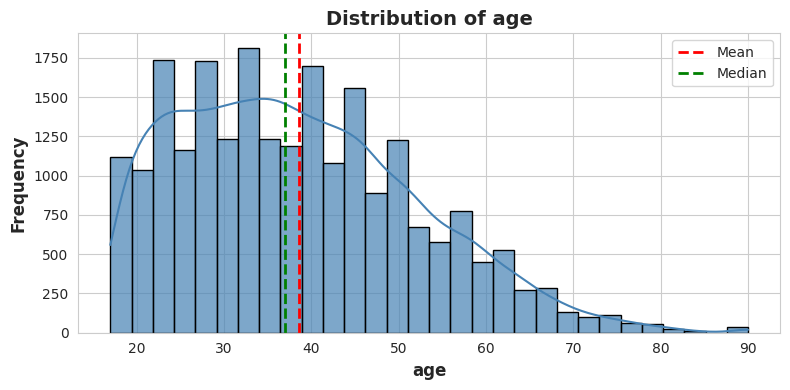

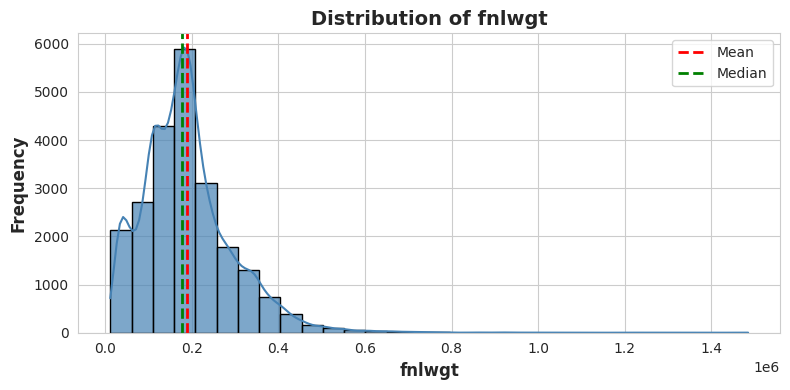

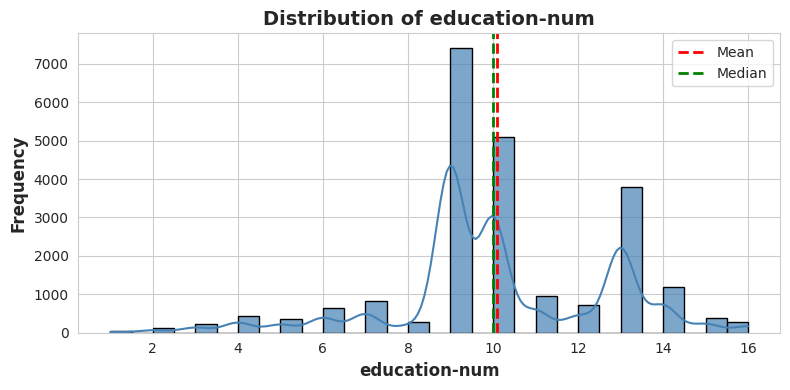

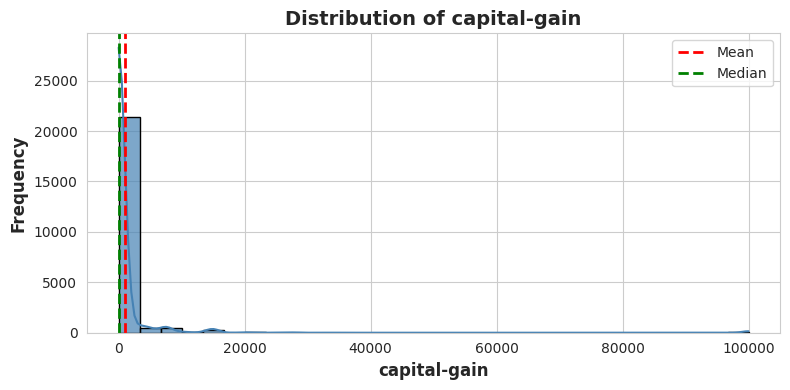

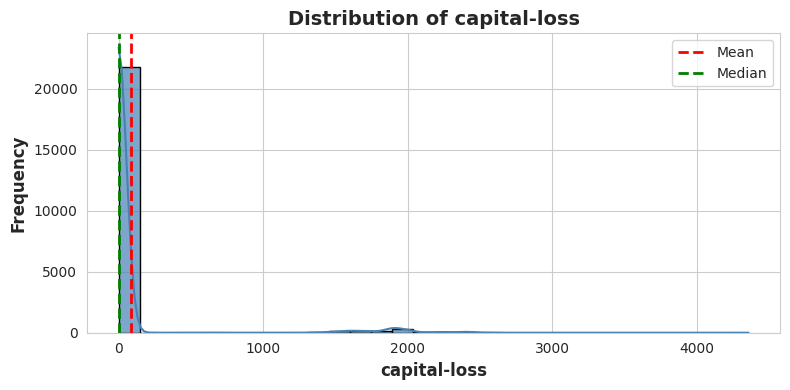

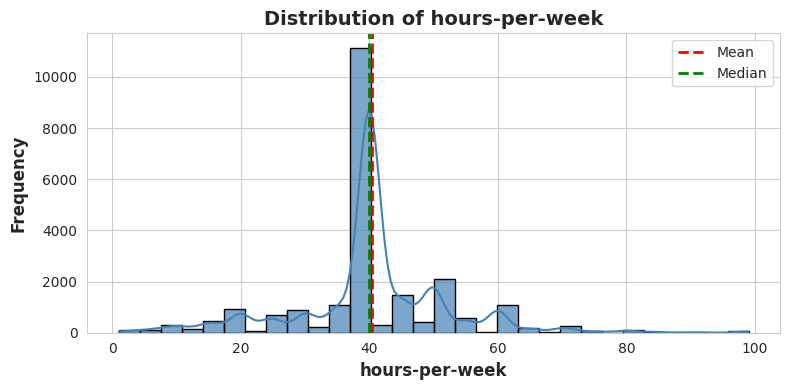

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(train_df[col], bins=30, kde=True, color="steelblue", edgecolor="black", alpha=0.7)

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.axvline(train_df[col].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    plt.axvline(train_df[col].median(), color='green', linestyle='--', linewidth=2, label='Median')
    plt.legend()
    plt.xlabel(col, fontsize=12, fontweight='bold')
    plt.ylabel("Frequency", fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

<ul>
<li>Most people are concentrated in the working-age range (around 25–50 years).</li>
<li>fnlwgt has very high variance and behaves like a noisy feature.</li>
<li>hours-per-week is mostly centered around 40 hours but contains outliers up to 99 hours.</li>
<li>capital-gain and capital-loss are highly skewed with most values equal to <li>zero and few extreme outliers.</li>
<li>education-num is relatively stable and more useful than raw education.</li>
<li>Most numerical features are not normally distributed, so robust scaling and <li>outlier handling are necessary.</li>
</ul>


**iii-categorical_columns**

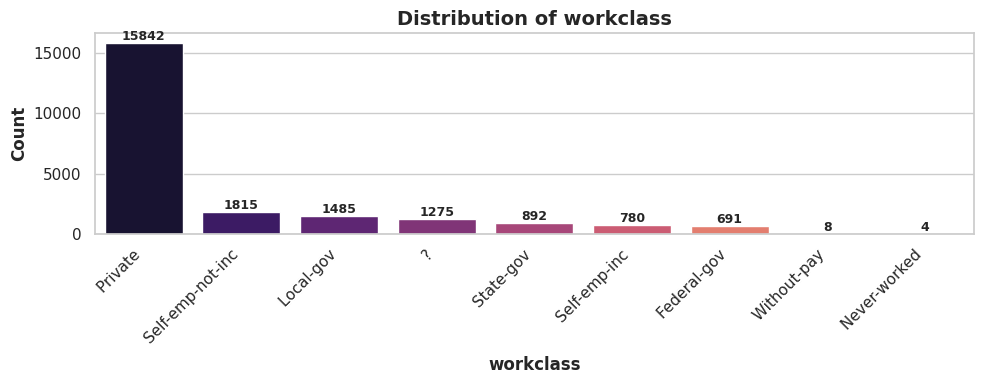

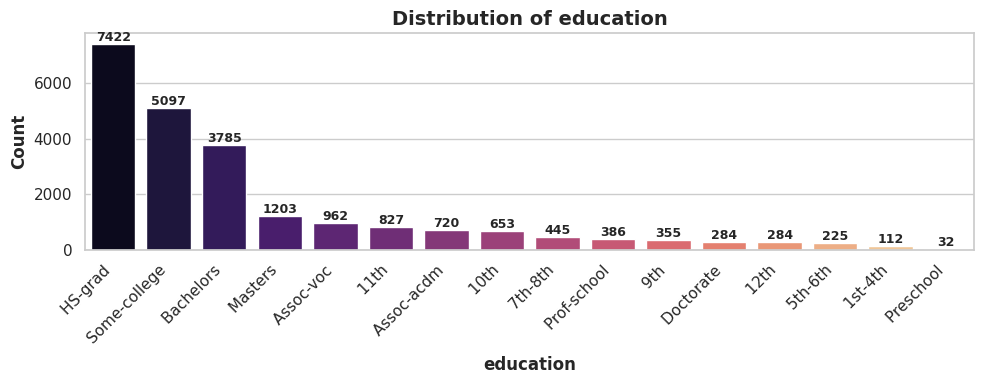

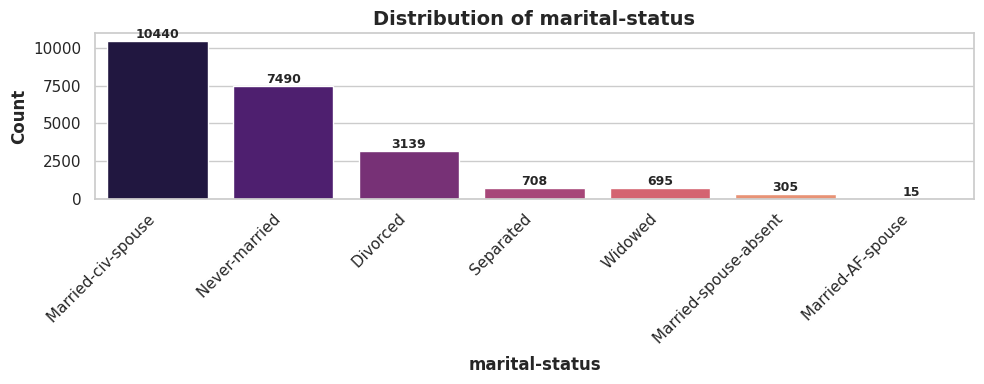

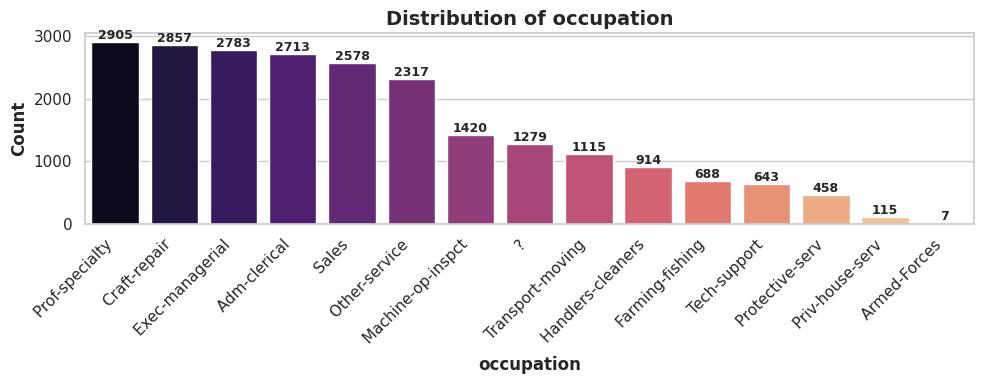

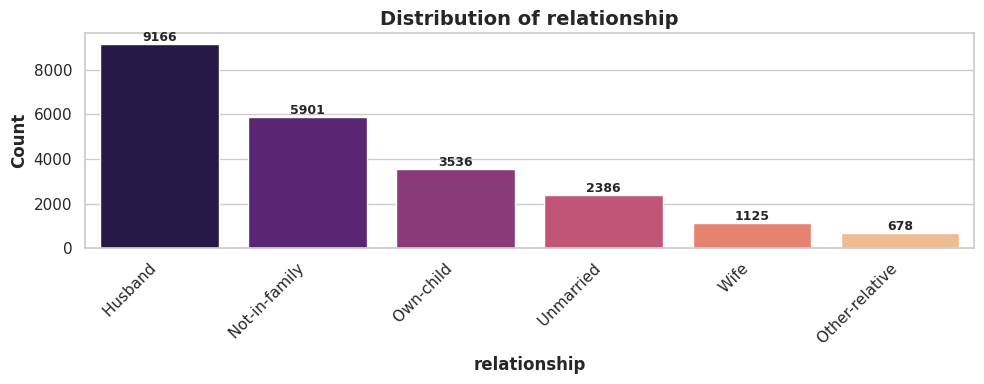

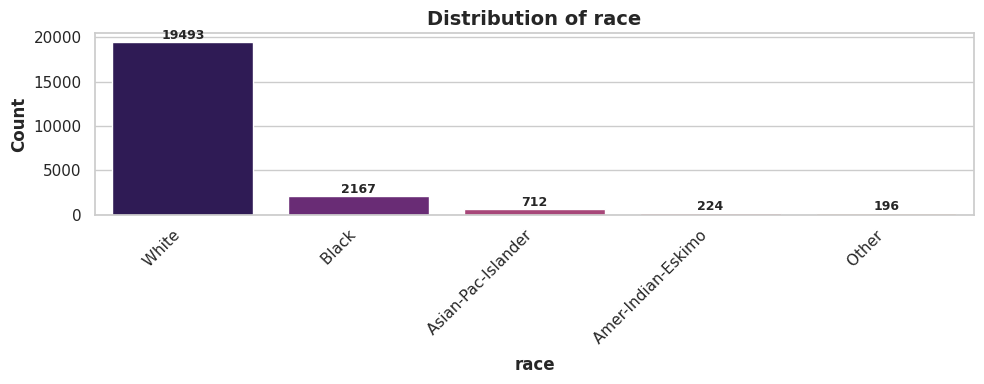

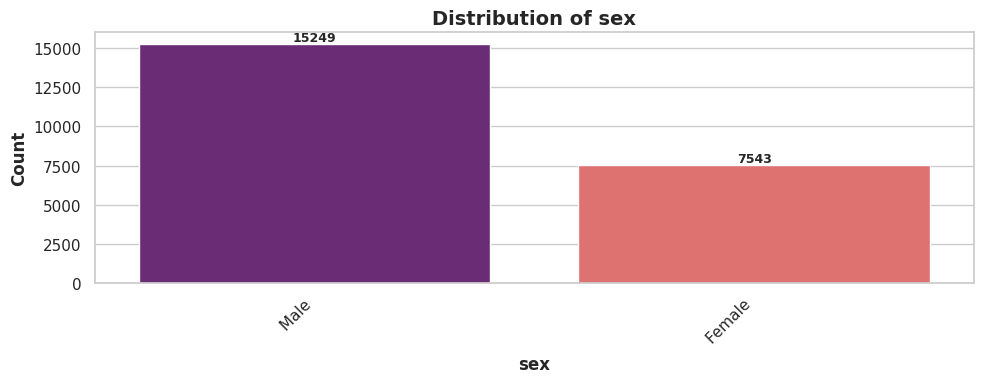

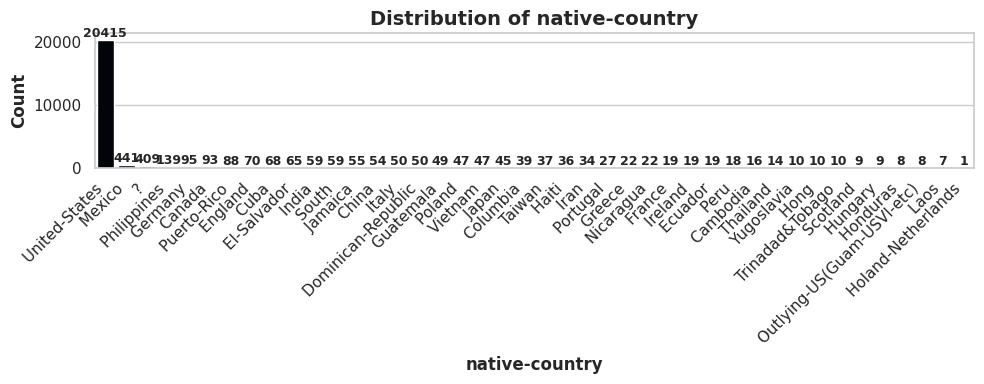

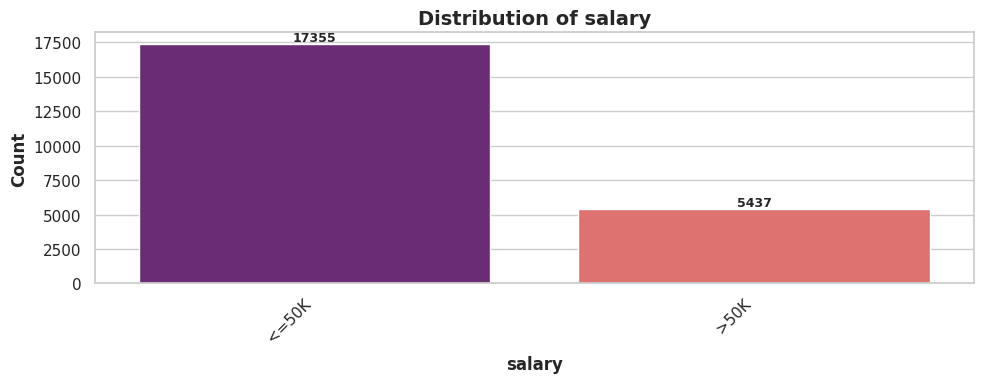

In [ ]:
sns.set_theme(style="whitegrid")
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    ax=sns.countplot(x=train_df[col],order=train_df[col].value_counts().index,palette="magma")

    plt.title(f'Distribution of {col}',fontsize=14,fontweight='bold')
    plt.xlabel(col,fontsize=12,fontweight='bold')
    plt.ylabel('Count',fontsize=12,fontweight='bold')
    plt.xticks(rotation=45,ha='right')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x()+p.get_width()/2,p.get_height()),
                    ha='center',va='bottom',fontsize=9,fontweight='bold')

    plt.tight_layout()
    plt.show()

<ul>
<li>workclass is mostly Private, with some "?" values (hidden missing data).</li>
<li>marital-status is dominated by Married-civ-spouse and Never-married.</li>
<li>relationship is mostly Husband, showing strong class concentration.</li>
<li>race is highly imbalanced, mainly White.</li>
<li>native-country is heavily dominated by United States.</li>
<li>education overlaps with education-num, so it's somewhat redundant.</li>
<li>Overall, categorical features are imbalanced and need proper encoding to avoid bias.</li>
</ul>

**v-features v.s target [Bivariate Analysis]**



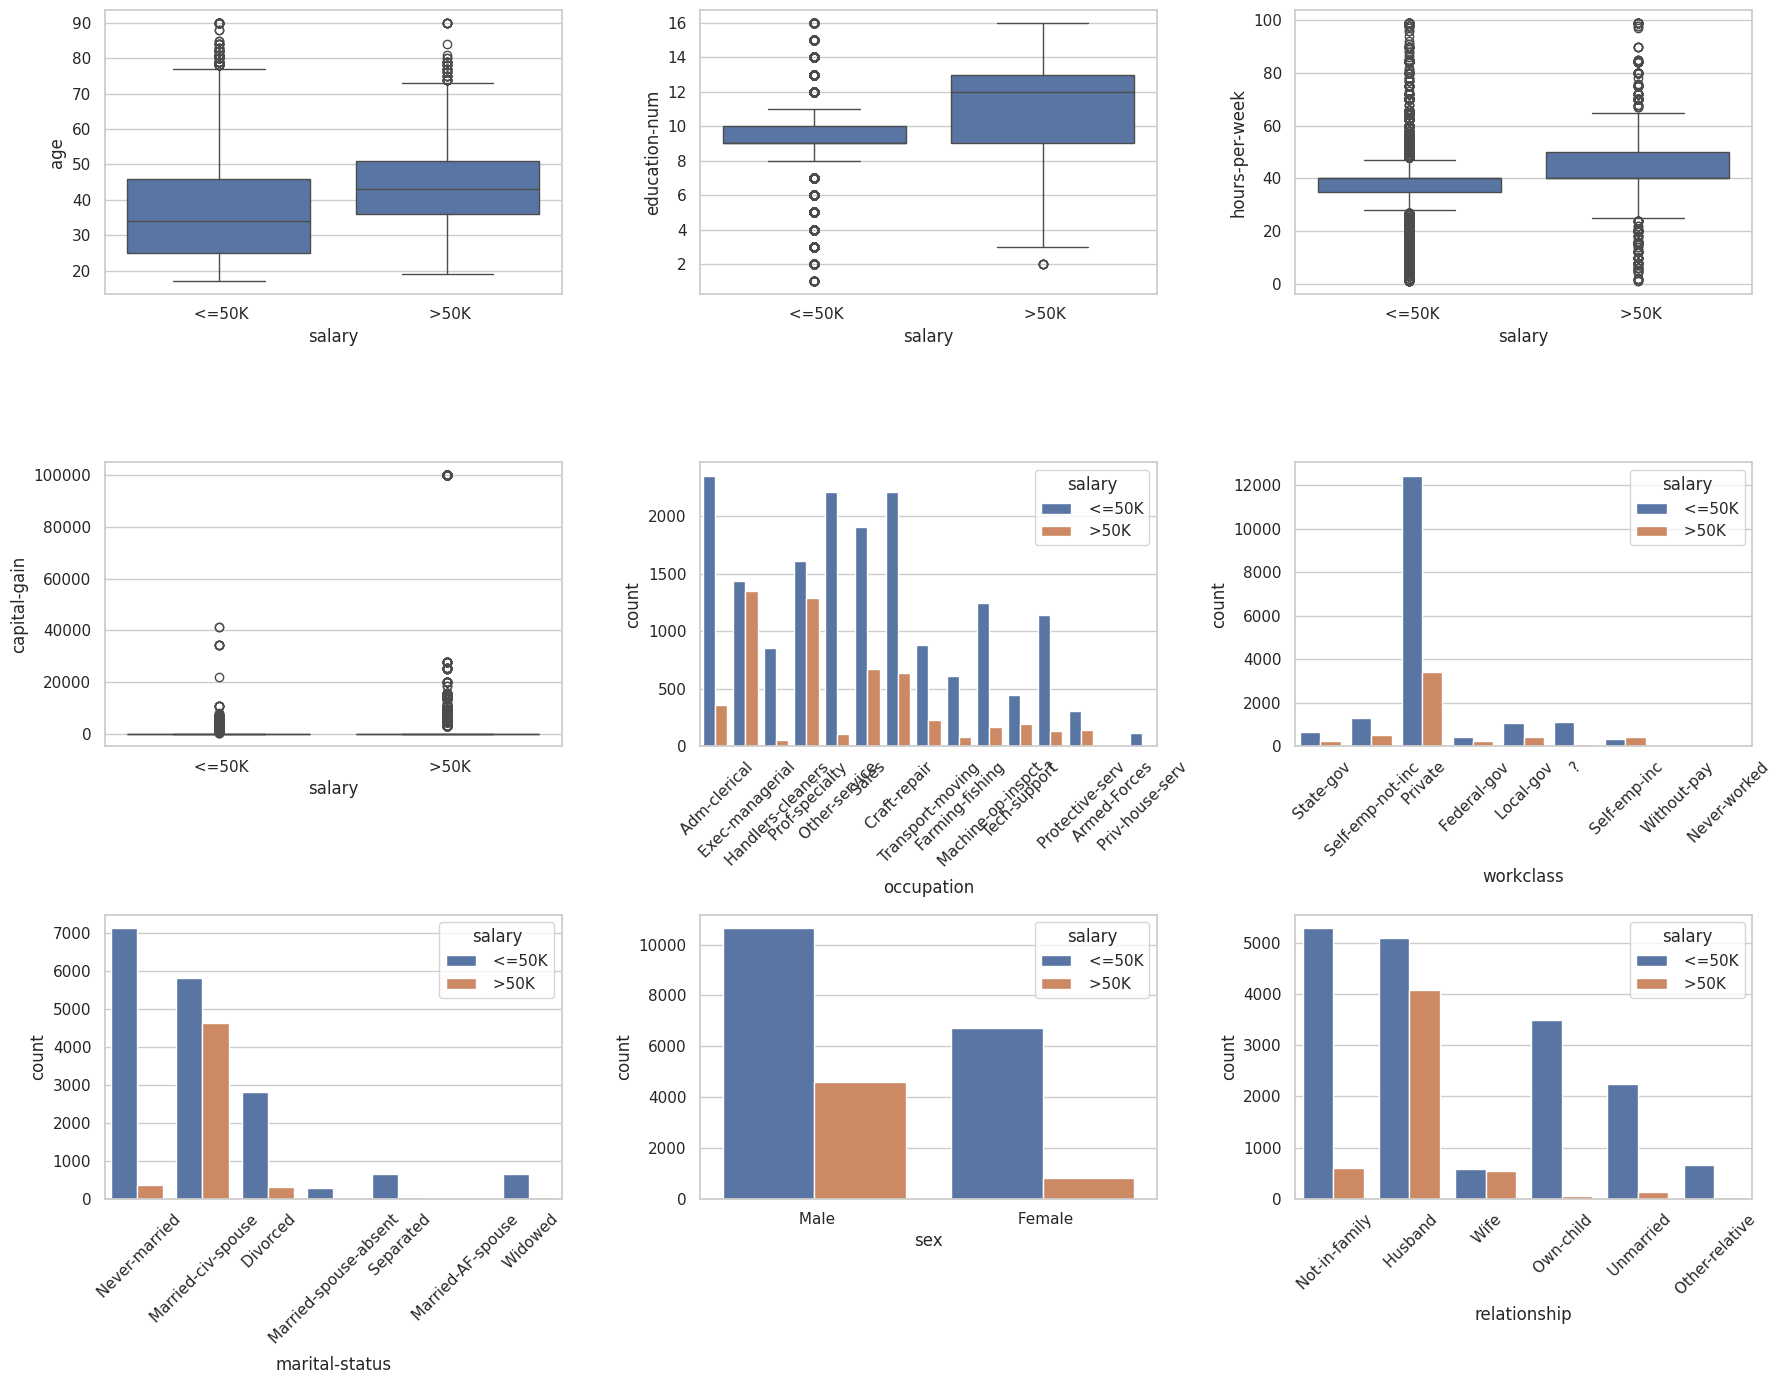

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

sns.boxplot(x="salary", y="age", data=train_df, ax=axes[0,0])
sns.boxplot(x="salary", y="education-num", data=train_df, ax=axes[0,1])
sns.boxplot(x="salary", y="hours-per-week", data=train_df, ax=axes[0,2])

sns.boxplot(x="salary", y="capital-gain", data=train_df, ax=axes[1,0])
sns.countplot(x="occupation", hue="salary", data=train_df, ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=45)

sns.countplot(x="workclass", hue="salary", data=train_df, ax=axes[1,2])
axes[1,2].tick_params(axis='x', rotation=45)

sns.countplot(x="marital-status", hue="salary", data=train_df, ax=axes[2,0])
axes[2,0].tick_params(axis='x', rotation=45)

sns.countplot(x="sex", hue="salary", data=train_df, ax=axes[2,1])

sns.countplot(x="relationship", hue="salary", data=train_df, ax=axes[2,2])
axes[2,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<ul>
<li>Education-num is one of the strongest predictors of higher salary.</li>
<li>Capital-gain is highly indicative of >50K when it is greater than zero.</li>
<li>Marital-status is very important, especially Married-civ-spouse.</li>
<li>Occupation strongly affects income, especially Exec-managerial and Prof-specialty.</li>
<li>Age shows that older individuals are more likely to earn >50K.</li>
<li>Hours-per-week has a weak positive relationship with higher salary.</li>
<li>Workclass affects income, with self-employed and government roles showing higher proportions of >50K than private sector.</li>
<li>Overall, salary depends mainly on education, occupation, marital status, and capital-gain.</li>
</ul>

**vi- 2 features + target [Trivariate Analysis]**

<Axes: xlabel='age', ylabel='education-num'>

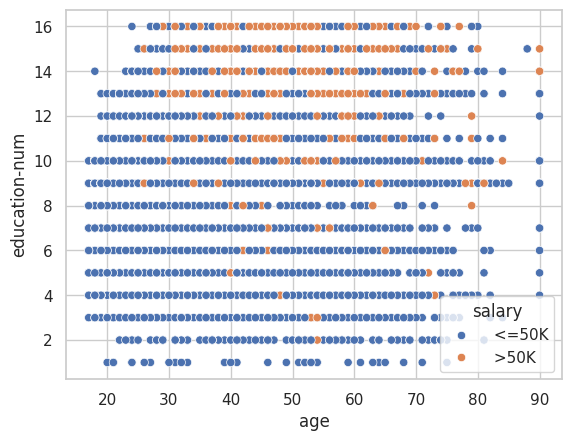

In [ ]:
sns.scatterplot(x="age", y="education-num", hue="salary", data=train_df)

<ul>
<li>Higher education levels combined with older age increase the likelihood of earning >50K, indicating that education and experience together drive income growth.</li>
</ul>

# **D. preprocessing**

In [ ]:
#z_scores = (train[num_cols] - train[num_cols].mean()) / train[num_cols].std()
#outliers= (z_scores.abs() > 3)
#print(outliers.sum())

<ul>
    <li>while Z-score assumes a normal distribution and can be distorted by these outliers..</li>
 <li>IQR is better here because the data is highly skewed and contains extreme outliers</li>
</ul>

In [ ]:
'''
outlier_num_cols = ['age', 'fnlwgt', 'education-num','hours-per-week']

def detectOutliers(outlier_num_cols):
  Q1=train_df[outlier_num_cols].quantile(0.25)
  Q3=train_df[outlier_num_cols].quantile(0.75)
  IQR= Q3-Q1

  upper= Q3+1.5*IQR
  lower=Q1-1.5*IQR

  return (train_df[outlier_num_cols] < lower ) | (train_df[outlier_num_cols] > upper )

for col in outlier_num_cols:
   print(col,"---->",detectOutliers(col).sum())
   '''

'\noutlier_num_cols = [\'age\', \'fnlwgt\', \'education-num\',\'hours-per-week\']\n\ndef detectOutliers(outlier_num_cols):\n  Q1=train_df[outlier_num_cols].quantile(0.25)\n  Q3=train_df[outlier_num_cols].quantile(0.75)\n  IQR= Q3-Q1\n\n  upper= Q3+1.5*IQR\n  lower=Q1-1.5*IQR\n\n  return (train_df[outlier_num_cols] < lower ) | (train_df[outlier_num_cols] > upper )\n\nfor col in outlier_num_cols:\n   print(col,"---->",detectOutliers(col).sum())\n   '

In [ ]:
'''
for i in outlier_num_cols:
    Q1 = train_df[i].quantile(0.25)
    Q3 = train_df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train_df[i] = train_df[i].clip(lower, upper)
    train_df[i] = train_df[i].clip(lower, upper)
'''

'\nfor i in outlier_num_cols:\n    Q1 = train_df[i].quantile(0.25)\n    Q3 = train_df[i].quantile(0.75)\n    IQR = Q3 - Q1\n\n    lower = Q1 - 1.5 * IQR\n    upper = Q3 + 1.5 * IQR\n\n    train_df[i] = train_df[i].clip(lower, upper)\n    train_df[i] = train_df[i].clip(lower, upper)\n'

In [ ]:
'''
for col in outlier_num_cols:
    print(col,"---->",detectOutliers(col).sum())
print("========")
for col in outlier_num_cols:
    print(col,"---->",detectOutliers(col).sum())
'''

'\nfor col in outlier_num_cols:\n    print(col,"---->",detectOutliers(col).sum())\nprint("========")\nfor col in outlier_num_cols:\n    print(col,"---->",detectOutliers(col).sum())\n'

In [ ]:
def basic_clean(train, test):
    train = train.copy(); test = test.copy()
    for dataset in [train, test]:
        for col in dataset.select_dtypes(include='object').columns:
            dataset[col] = dataset[col].str.strip()
    train = train.replace('?', np.nan)
    test  = test.replace('?', np.nan)
    before = len(train)  #number of rows before delete drop_duplicates
    train = train.drop_duplicates().reset_index(drop=True)
    print(f'Dropped duplicate train rows: {before - len(train)}')
    for col in ['workclass', 'occupation', 'native-country']:
        mode_val = train[col].mode()[0]
        train[col] = train[col].fillna(mode_val)
        test[col]  = test[col].fillna(mode_val)    #test must fill by train mode not test
    return train, test

train_clean, test_clean = basic_clean(train_df, test_df)
print('Remaining missing — train:', train_clean.isna().sum().sum(),
      ' | test:', test_clean.isna().sum().sum())   # check no nulls

Dropped duplicate train rows: 15
Remaining missing — train: 0  | test: 0


## **E. Feature Engineering**

In [ ]:
def add_features(train, test):
    train = train.copy(); test = test.copy()
    for ds in [train, test]:
        ds['capital_gain_log'] = np.log1p(ds['capital-gain'])
        ds['capital_loss_log'] = np.log1p(ds['capital-loss'])
        ds['capital_net_log']  = ds['capital_gain_log'] - ds['capital_loss_log']
        ds['is_any_capital']   = ((ds['capital-gain'] > 0) | (ds['capital-loss'] > 0)).astype(int)
        ds['works_overtime']   = (ds['hours-per-week'] > 40).astype(int)
        ds['is_us']            = (ds['native-country'] == 'United-States').astype(int)
        ds['is_married']       = ds['marital-status'].isin(
            ['Married-civ-spouse', 'Married-AF-spouse']).astype(int)
    for ds_list in [train, test]:
        pass
    train = train.drop(columns=['capital-gain', 'capital-loss', 'education', 'race', 'fnlwgt'])
    test  = test.drop(columns=['capital-gain', 'capital-loss', 'education', 'race', 'fnlwgt'])
    return train, test

train_fe, test_fe = add_features(train_clean, test_clean)
print('Shape after feature engineering:', train_fe.shape, test_fe.shape)
display(train_fe.head(3))

Shape after feature engineering: (22777, 17) (9769, 17)


,age,workclass,education-num,marital-status,occupation,relationship,sex,hours-per-week,native-country,salary,capital_gain_log,capital_loss_log,capital_net_log,is_any_capital,works_overtime,is_us,is_married
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,Male,40,United-States,<=50K,7.684784,0.0,7.684784,1,0,1,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,Male,13,United-States,<=50K,0.000000,0.0,0.000000,0,0,1,1
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,Male,40,United-States,<=50K,0.000000,0.0,0.000000,0,0,1,0


# **F.Prepare Features and Target**

In [ ]:
salary_map = {'<=50K': 0, '>50K': 1}
train_fe['salary'] = train_fe['salary'].map(salary_map)
test_fe['salary']  = test_fe['salary'].map(salary_map)

X = train_fe.drop(columns=['salary'])
y = train_fe['salary']
X_test_final  = test_fe.drop(columns=['salary'])
y_test_final  = test_fe['salary']

print('X shape:', X.shape, '| Test shape:', X_test_final.shape)
print('Train class distribution:')
display(y.value_counts().rename({0: '<=50K', 1: '>50K'}))

X shape: (22777, 16) | Test shape: (9769, 16)
Train class distribution:


,count
salary,
<=50K,17340
>50K,5437


* SMOTE is better than RandomOverSampler because it creates new synthetic samples instead of just duplicating existing ones,  This helps the model generalize better and reduces overfitting , while RandomOverSampler only copies existing minority samples, which may cause the model to memorize them.

SMOTE also works on numeric features only, so it is applied after preprocessing inside the pipeline.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Quick numeric encoding just for the SMOTE preview
_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_enc = _enc.fit_transform(X.select_dtypes(include='object').join(X.select_dtypes(exclude='object')))

smote_prev = SMOTE(random_state=30, k_neighbors=5)
X_res_prev, y_res_prev = smote_prev.fit_resample(X_enc, y)

print('Before SMOTE:')
print(y.value_counts().rename({0: '<=50K', 1: '>50K'}))
print("========================================================")
print('After SMOTE preview:')
print(y_res_prev.value_counts().rename({0: '<=50K', 1: '>50K'}))

Before SMOTE:
salary
<=50K    17340
>50K      5437
Name: count, dtype: int64
After SMOTE preview:
salary
<=50K    17340
>50K     17340
Name: count, dtype: int64


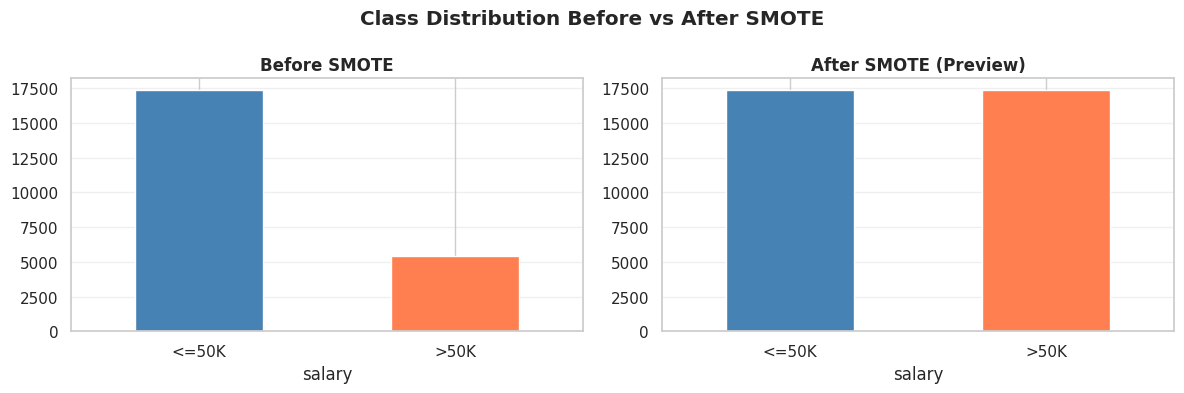

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Before SMOTE
y.value_counts().rename({0: '<=50K', 1: '>50K'}).plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontweight='bold'); axes[0].set_xticklabels(['<=50K', '>50K'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)
# after SMOTE
y_res_prev.value_counts().rename({0: '<=50K', 1: '>50K'}).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('After SMOTE (Preview)', fontweight='bold'); axes[1].set_xticklabels(['<=50K', '>50K'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('Class Distribution Before vs After SMOTE', fontweight='bold')
plt.tight_layout(); plt.show()

## **correlation**


## **G. Preprocessing Pipelines**

In [ ]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features    = X.select_dtypes(exclude='object').columns.tolist()
print('Categorical:', categorical_features)
print('Numeric:    ', numeric_features)

def make_ohe():
    try:    return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except: return OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess_scaled = ColumnTransformer([
    ('cat', make_ohe(), categorical_features),
    ('num', StandardScaler(), numeric_features)
], remainder='drop')

preprocess_tree = ColumnTransformer([
    ('cat', make_ohe(), categorical_features),
    ('num', 'passthrough', numeric_features)
], remainder='drop')
print("Pipelines ready.")

preprocess_boost = ColumnTransformer([
    ('cat', 'passthrough', categorical_features),
    ('num', 'passthrough', numeric_features)
], remainder='drop')

preprocess_boost.set_output(transform='pandas')

Categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'sex', 'native-country']
Numeric:     ['age', 'education-num', 'hours-per-week', 'capital_gain_log', 'capital_loss_log', 'capital_net_log', 'is_any_capital', 'works_overtime', 'is_us', 'is_married']
Pipelines ready.


ColumnTransformer(transformers=[('cat', 'passthrough',
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'sex', 'native-country']),
                                ('num', 'passthrough',
                                 ['age', 'education-num', 'hours-per-week',
                                  'capital_gain_log', 'capital_loss_log',
                                  'capital_net_log', 'is_any_capital',
                                  'works_overtime', 'is_us', 'is_married'])])


# **H. Model Definitions (SMOTE IN and OUT)**

In [ ]:
SMOTE_PARAMS = dict(random_state=30, k_neighbors=5)

models = {
    'Logistic Regression': SklearnPipeline([
        ('prep', preprocess_scaled),
        ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),
    'Logistic Regression + SMOTE': ImbPipeline([
        ('prep', preprocess_scaled),
        ('smote', SMOTE(**SMOTE_PARAMS)),
        ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),
    'KNN': SklearnPipeline([
        ('prep', preprocess_scaled),
        ('clf', KNeighborsClassifier(n_neighbors=11))
    ]),
    'KNN + SMOTE': ImbPipeline([
        ('prep', preprocess_scaled),
        ('smote', SMOTE(**SMOTE_PARAMS)),
        ('clf', KNeighborsClassifier(n_neighbors=11))
    ]),
    'SVM': SklearnPipeline([
        ('prep', preprocess_scaled),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                    random_state=RANDOM_STATE))
    ]),
    'SVM + SMOTE': ImbPipeline([
        ('prep', preprocess_scaled),
        ('smote', SMOTE(**SMOTE_PARAMS)),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                    random_state=RANDOM_STATE))
    ]),
    'Decision Tree': SklearnPipeline([
        ('prep', preprocess_tree),
        ('clf', DecisionTreeClassifier(
            max_depth=12,
            min_samples_leaf=20,
            random_state=RANDOM_STATE
        ))
    ]),
    'Decision Tree + SMOTE': ImbPipeline([
        ('prep', preprocess_tree),
        ('smote', SMOTE(**SMOTE_PARAMS)),
        ('clf', DecisionTreeClassifier(
            max_depth=12,
            min_samples_leaf=20,
            random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': SklearnPipeline([
        ('prep', preprocess_tree),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    'Random Forest + SMOTE': ImbPipeline([
        ('prep', preprocess_tree),
        ('smote', SMOTE(**SMOTE_PARAMS)),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}
# =========================
# CatBoost
# =========================

try:
    from catboost import CatBoostClassifier

    catboost_params = dict(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=False
    )
    models['CatBoost'] = SklearnPipeline([
        ('prep', preprocess_boost),
        ('clf', CatBoostClassifier(**catboost_params))
    ])
    models['CatBoost + SMOTE'] = ImbPipeline([
        ('prep', preprocess_tree),
        ('smote', SMOTE(**SMOTE_PARAMS)),
        ('clf', CatBoostClassifier(**catboost_params))
    ])
    print('CatBoost added.')
except Exception as e:
    print('CatBoost not available:', e)

# =========================
# XGBoost
# =========================

try:
    from xgboost import XGBClassifier

    _xgb_params = dict(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    models['XGBoost'] = SklearnPipeline([
        ('prep', preprocess_tree),
        ('clf', XGBClassifier(**_xgb_params))
    ])
    models['XGBoost + SMOTE'] = ImbPipeline([
        ('prep', preprocess_tree),
        ('smote', SMOTE(**SMOTE_PARAMS)),
        ('clf', XGBClassifier(**_xgb_params))
    ])
    print('XGBoost added.')
except Exception as e:
    print('XGBoost not available:', e)

print('Total models:', len(models))
for n in models:
    print(' -', n)

CatBoost added.
XGBoost added.
Total models: 14
 - Logistic Regression
 - Logistic Regression + SMOTE
 - KNN
 - KNN + SMOTE
 - SVM
 - SVM + SMOTE
 - Decision Tree
 - Decision Tree + SMOTE
 - Random Forest
 - Random Forest + SMOTE
 - CatBoost
 - CatBoost + SMOTE
 - XGBoost
 - XGBoost + SMOTE


# **I.Evaluations**

Cross-Validation Comparison (5-Fold Stratified)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for model_name, model in models.items():
    fold_scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

    for train_idx, val_idx in skf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Special handling for CatBoost (raw categorical data)
        if model_name == 'CatBoost':
            model_clone = models[model_name]  # use original pipeline (it will be re‑fitted)
            model_clone.fit(X_train_fold, y_train_fold, clf__cat_features=list(range(len(categorical_features))))
        else:
            model_clone = models[model_name]  # still need a fresh clone for each fold
            model_clone.fit(X_train_fold, y_train_fold)

        y_pred_fold = model_clone.predict(X_val_fold)

        fold_scores['accuracy'].append(accuracy_score(y_val_fold, y_pred_fold))
        fold_scores['precision'].append(precision_score(y_val_fold, y_pred_fold))
        fold_scores['recall'].append(recall_score(y_val_fold, y_pred_fold))
        fold_scores['f1'].append(f1_score(y_val_fold, y_pred_fold))

    cv_rows.append({
        'Model': model_name,
        'CV Accuracy': np.mean(fold_scores['accuracy']),
        'CV Accuracy Std': np.std(fold_scores['accuracy']),
        'CV Precision >50K': np.mean(fold_scores['precision']),
        'CV Recall >50K': np.mean(fold_scores['recall']),
        'CV F1 >50K': np.mean(fold_scores['f1']),
    })

cv_results = (pd.DataFrame(cv_rows)
              .sort_values('CV Accuracy', ascending=False)
              .reset_index(drop=True))

display(cv_results.style.format({c: '{:.4f}' for c in cv_results.columns if c != 'Model'}))

,Model,CV Accuracy,CV Accuracy Std,CV Precision >50K,CV Recall >50K,CV F1 >50K
0,CatBoost,0.8708,0.0045,0.7828,0.6351,0.7011
1,XGBoost,0.8696,0.0035,0.7826,0.6285,0.6970
2,Random Forest,0.8636,0.0050,0.7815,0.5948,0.6754
3,CatBoost + SMOTE,0.8611,0.0053,0.7049,0.7191,0.7119
4,XGBoost + SMOTE,0.8557,0.0036,0.6814,0.7429,0.7108
5,Random Forest + SMOTE,0.8543,0.0040,0.6939,0.6973,0.6955
6,Decision Tree,0.8536,0.0029,0.7603,0.5663,0.6482
7,SVM,0.8528,0.0045,0.7536,0.5694,0.6486
8,Logistic Regression,0.8520,0.0058,0.7374,0.5902,0.6555
9,KNN,0.8412,0.0054,0.6838,0.6220,0.6514


## **J. Official Test Set Evaluation**

In [ ]:
test_rows = []
fitted_models = {}

for model_name, model in models.items():
    print(f'Fitting: {model_name}')

    if model_name == 'CatBoost':
        model.fit(X, y, clf__cat_features=list(range(len(categorical_features))))
    else:
        model.fit(X, y)

    y_pred = model.predict(X_test_final)
    fitted_models[model_name] = model
    test_rows.append({
        'Model': model_name,
        'Test Accuracy':       accuracy_score(y_test_final, y_pred),
        'Test Precision >50K': precision_score(y_test_final, y_pred),
        'Test Recall >50K':    recall_score(y_test_final, y_pred),
        'Test F1 >50K':        f1_score(y_test_final, y_pred),
    })

test_results = (pd.DataFrame(test_rows)
                .sort_values('Test Accuracy', ascending=False)
                .reset_index(drop=True))

display(test_results.style.format({c: '{:.4f}' for c in test_results.columns if c != 'Model'}))

Fitting: Logistic Regression
Fitting: Logistic Regression + SMOTE
Fitting: KNN
Fitting: KNN + SMOTE
Fitting: SVM
Fitting: SVM + SMOTE
Fitting: Decision Tree
Fitting: Decision Tree + SMOTE
Fitting: Random Forest
Fitting: Random Forest + SMOTE
Fitting: CatBoost
Fitting: CatBoost + SMOTE
Fitting: XGBoost
Fitting: XGBoost + SMOTE


,Model,Test Accuracy,Test Precision >50K,Test Recall >50K,Test F1 >50K
0,CatBoost,0.8757,0.7975,0.6635,0.7243
1,XGBoost,0.8753,0.8022,0.6547,0.7210
2,Random Forest,0.8727,0.8046,0.6373,0.7112
3,CatBoost + SMOTE,0.8698,0.7306,0.7458,0.7382
4,XGBoost + SMOTE,0.8622,0.6980,0.7758,0.7348
5,Random Forest + SMOTE,0.8601,0.7110,0.7267,0.7188
6,Decision Tree,0.8583,0.7885,0.5799,0.6683
7,Logistic Regression,0.8545,0.7540,0.6069,0.6725
8,SVM,0.8542,0.7620,0.5928,0.6668
9,KNN,0.8469,0.7086,0.6414,0.6734


## **K. Dual Best-Model Selection**

* The models are compared using both Accuracy and F1-Score.

Accuracy measures overall performance, while F1-Score focuses on the minority class (>50K).

The final best model is selected after comparing all results.

In [ ]:
# ── Best by Accuracy ──────────────────────────────────────────────────────────
best_acc_idx   = test_results['Test Accuracy'].idxmax()
best_acc_row   = test_results.loc[best_acc_idx]
best_acc_name  = best_acc_row['Model']

print("=" * 60)
print(f"BEST MODEL BY ACCURACY: {best_acc_name}")
print("=" * 60)
print(f"  Test Accuracy :  {best_acc_row['Test Accuracy']:.4f}")
print(f"  Test Precision:  {best_acc_row['Test Precision >50K']:.4f}")
print(f"  Test Recall   :  {best_acc_row['Test Recall >50K']:.4f}")
print(f"  Test F1 >50K  :  {best_acc_row['Test F1 >50K']:.4f}")
print()

# ── Best by F1 (classification report proxy) ─────────────────────────────────
best_f1_idx  = test_results['Test F1 >50K'].idxmax()
best_f1_row  = test_results.loc[best_f1_idx]
best_f1_name = best_f1_row['Model']

print("=" * 60)
print(f"BEST MODEL BY F1 >50K: {best_f1_name}")
print("=" * 60)
print(f"  Test Accuracy :  {best_f1_row['Test Accuracy']:.4f}")
print(f"  Test Precision:  {best_f1_row['Test Precision >50K']:.4f}")
print(f"  Test Recall   :  {best_f1_row['Test Recall >50K']:.4f}")
print(f"  Test F1 >50K  :  {best_f1_row['Test F1 >50K']:.4f}")

# ── Final Best Model ──────────────────────────────────────────────────────────
# Composite score: equal weight on Accuracy + F1 (normalised implicitly since both 0-1)
test_results['Composite Score'] = (
    0.5 * test_results['Test Accuracy'] + 0.5 * test_results['Test F1 >50K']
)
final_best_idx  = test_results['Composite Score'].idxmax()
final_best_row  = test_results.loc[final_best_idx]
final_best_name = final_best_row['Model']

print()
print("=" * 60)
print(f"FINAL BEST MODEL (Accuracy + F1 composite): {final_best_name}")
print("=" * 60)
print(f"  Test Accuracy    :  {final_best_row['Test Accuracy']:.4f}")
print(f"  Test Precision   :  {final_best_row['Test Precision >50K']:.4f}")
print(f"  Test Recall      :  {final_best_row['Test Recall >50K']:.4f}")
print(f"  Test F1 >50K     :  {final_best_row['Test F1 >50K']:.4f}")
print(f"  Composite Score  :  {final_best_row['Composite Score']:.4f}")


BEST MODEL BY ACCURACY: CatBoost
  Test Accuracy :  0.8757
  Test Precision:  0.7975
  Test Recall   :  0.6635
  Test F1 >50K  :  0.7243

BEST MODEL BY F1 >50K: CatBoost + SMOTE
  Test Accuracy :  0.8698
  Test Precision:  0.7306
  Test Recall   :  0.7458
  Test F1 >50K  :  0.7382

FINAL BEST MODEL (Accuracy + F1 composite): CatBoost + SMOTE
  Test Accuracy    :  0.8698
  Test Precision   :  0.7306
  Test Recall      :  0.7458
  Test F1 >50K     :  0.7382
  Composite Score  :  0.8040


## . Final Best Model Ever — Full Evaluation

 FINAL BEST MODEL: CatBoost + SMOTE
Test Accuracy : 0.8698

Full Classification Report:
              precision    recall  f1-score   support

       <=50K       0.92      0.91      0.91      7365
        >50K       0.73      0.75      0.74      2404

    accuracy                           0.87      9769
   macro avg       0.82      0.83      0.83      9769
weighted avg       0.87      0.87      0.87      9769



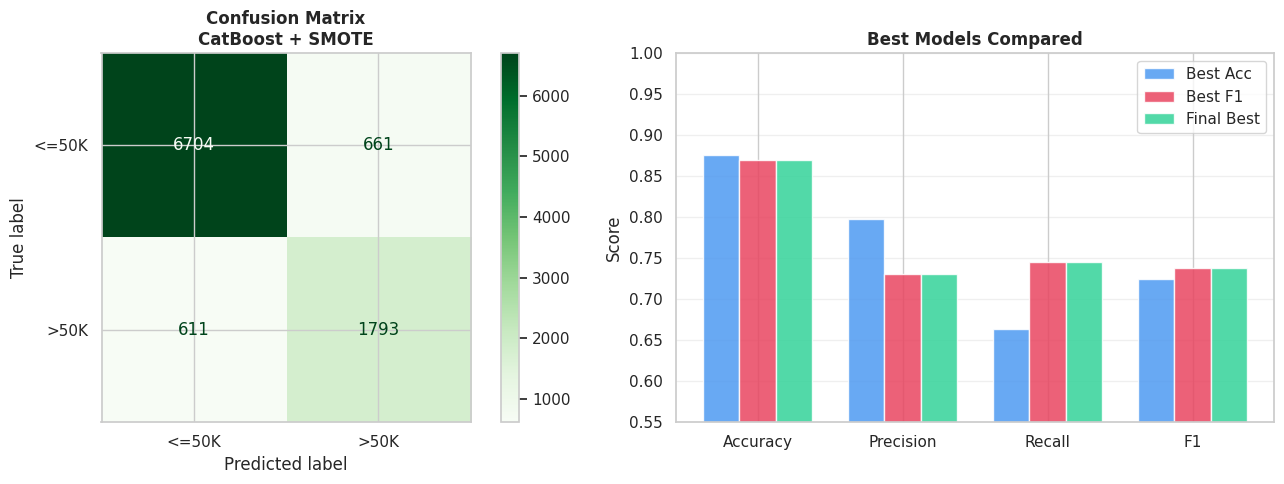

In [ ]:
model_final = fitted_models[final_best_name]
y_pred_final = model_final.predict(X_test_final)

print("=" * 60)
print(f" FINAL BEST MODEL: {final_best_name}")
print("=" * 60)
print(f"Test Accuracy : {accuracy_score(y_test_final, y_pred_final):.4f}")
print()
print("Full Classification Report:")
print(classification_report(y_test_final, y_pred_final, target_names=['<=50K', '>50K']))

cm3 = confusion_matrix(y_test_final, y_pred_final)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm3, display_labels=['<=50K', '>50K']).plot(ax=axes[0], cmap='Greens')
axes[0].set_title(f'Confusion Matrix\n{final_best_name}', fontweight='bold')

# Radar chart for the three winners
categories = ['Accuracy', 'Precision', 'Recall', 'F1']
winners = {
    'Best Acc': [best_acc_row['Test Accuracy'], best_acc_row['Test Precision >50K'],
                 best_acc_row['Test Recall >50K'], best_acc_row['Test F1 >50K']],
    'Best F1':  [best_f1_row['Test Accuracy'],  best_f1_row['Test Precision >50K'],
                 best_f1_row['Test Recall >50K'],  best_f1_row['Test F1 >50K']],
    'Final Best': [final_best_row['Test Accuracy'], final_best_row['Test Precision >50K'],
                   final_best_row['Test Recall >50K'], final_best_row['Test F1 >50K']],
}
x = np.arange(len(categories)); w2 = 0.25
colors_w = ['#4e9af1', '#e94560', '#34d399']
for i, (name, vals) in enumerate(winners.items()):
    axes[1].bar(x + (i-1)*w2, vals, w2, label=name, color=colors_w[i], alpha=0.85, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(categories)
axes[1].set_ylim(0.55, 1.0); axes[1].set_ylabel('Score')
axes[1].set_title('Best Models Compared', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


# **GUI**

In [ ]:
# impotr and install gradio
!pip install gradio
import gradio as gr

In [ ]:

# PREDICTION FUNCTION

def predict_income(
    age,
    hours_per_week,
    capital_gain,
    capital_loss,
    education,
    workclass,
    occupation,
    marital_status,
    relationship,
    sex,
    race,
    native_country
):

    # RAW INPUT

    input_data = pd.DataFrame([{
        "age": age,
        "workclass": workclass,
        "education": education,
        "marital-status": marital_status,
        "occupation": occupation,
        "relationship": relationship,
        "race": race,
        "sex": sex,
        "capital-gain": capital_gain,
        "capital-loss": capital_loss,
        "hours-per-week": hours_per_week,
        "native-country": native_country
    }])



    # FEATURE ENGINEERING

    input_data['capital_gain_log'] = np.log1p(
        input_data['capital-gain']
    )

    input_data['capital_loss_log'] = np.log1p(
        input_data['capital-loss']
    )

    input_data['capital_net_log'] = (
        input_data['capital_gain_log']
        - input_data['capital_loss_log']
    )

    input_data['is_any_capital'] = (
        (
            (input_data['capital-gain'] > 0)
            |
            (input_data['capital-loss'] > 0)
        ).astype(int)
    )

    input_data['works_overtime'] = (
        input_data['hours-per-week'] > 40
    ).astype(int)

    input_data['is_us'] = (
        input_data['native-country'] == 'United-States'
    ).astype(int)

    input_data['is_married'] = (
        input_data['marital-status'].isin([
            'Married-civ-spouse',
            'Married-AF-spouse'
        ])
    ).astype(int)


    # EDUCATION NUM

    education_map = {
        "Preschool": 1,
        "1st-4th": 2,
        "5th-6th": 3,
        "7th-8th": 4,
        "9th": 5,
        "10th": 6,
        "11th": 7,
        "12th": 8,
        "HS-grad": 9,
        "Some-college": 10,
        "Assoc-voc": 11,
        "Assoc-acdm": 12,
        "Bachelors": 13,
        "Masters": 14,
        "Prof-school": 15,
        "Doctorate": 16
    }

    input_data['education-num'] = input_data['education'].map(
        education_map
    )


    # DROP SAME TRAIN COLS

    input_data = input_data.drop(columns=[
        'capital-gain',
        'capital-loss',
        'education',
        'race'
    ])



    # REORDER COLUMNS

    input_data = input_data[X.columns]



    # ENCODE

    input_data[categorical_features] = encoder.transform(
        input_data[categorical_features]
    )


    # PREDICT

    pred = model.predict(input_data)[0]



    # OUTPUT

    if int(pred) == 1:
        return "Prediction: >50K"
    else:
        return "Prediction: <=50K"


# GUI

demo = gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="purple"
    )
)

with demo:

    gr.Markdown("# 💼 Income Prediction")

    age = gr.Slider(
        18,
        90,
        step=1,
        label="Age"
    )

    hours = gr.Slider(
        1,
        100,
        step=1,
        label="Hours per Week"
    )

    capital_gain = gr.Number(
        label="Capital Gain",
        value=0
    )

    capital_loss = gr.Number(
        label="Capital Loss",
        value=0
    )

    education = gr.Dropdown(
        [
            'Bachelors',
            'HS-grad',
            '11th',
            'Masters',
            '9th',
            'Some-college',
            'Assoc-acdm',
            'Assoc-voc',
            '7th-8th',
            'Doctorate',
            'Prof-school',
            '5th-6th',
            '10th',
            '1st-4th',
            'Preschool',
            '12th'
        ],
        label="Education"
    )

    workclass = gr.Dropdown(
        [
            'State-gov',
            'Self-emp-not-inc',
            'Private',
            'Federal-gov',
            'Local-gov',
            'Self-emp-inc',
            'Without-pay',
            'Never-worked'
        ],
        label="Workclass"
    )

    occupation = gr.Dropdown(
        [
            'Adm-clerical',
            'Exec-managerial',
            'Handlers-cleaners',
            'Prof-specialty',
            'Other-service',
            'Sales',
            'Craft-repair',
            'Transport-moving',
            'Farming-fishing',
            'Machine-op-inspct',
            'Tech-support',
            'Protective-serv',
            'Armed-Forces',
            'Priv-house-serv'
        ],
        label="Occupation"
    )

    marital_status = gr.Dropdown(
        [
            'Never-married',
            'Married-civ-spouse',
            'Divorced',
            'Married-spouse-absent',
            'Separated',
            'Married-AF-spouse',
            'Widowed'
        ],
        label="Marital Status"
    )

    relationship = gr.Dropdown(
        [
            'Not-in-family',
            'Husband',
            'Wife',
            'Own-child',
            'Unmarried',
            'Other-relative'
        ],
        label="Relationship"
    )

    sex = gr.Dropdown(
        [
            "Male",
            "Female"
        ],
        label="Sex"
    )

    race = gr.Dropdown(
        [
            'White',
            'Black',
            'Asian-Pac-Islander',
            'Amer-Indian-Eskimo',
            'Other'
        ],
        label="Race"
    )

    native_country = gr.Dropdown(
        [
            'United-States',
            'India',
            'Canada',
            'Germany',
            'England',
            'Mexico'
        ],
        label="Native Country"
    )

    btn = gr.Button("Predict Income 🚀")

    out = gr.Textbox(
        label="Prediction Result"
    )

    btn.click(
        fn=predict_income,
        inputs=[
            age,
            hours,
            capital_gain,
            capital_loss,
            education,
            workclass,
            occupation,
            marital_status,
            relationship,
            sex,
            race,
            native_country
        ],
        outputs=out
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6cc0509af9f6e3f169.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
